In [15]:
from google.colab import files
uploaded = files.upload()


Saving churn.csv to churn.csv


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [19]:
df = pd.read_csv("churn.csv")
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [20]:
df = df.dropna()

In [21]:
le = LabelEncoder()
for col in df.select_dtypes(include=['object']):
    df[col] = le.fit_transform(df[col])

In [22]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [23]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

In [26]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [27]:
def evaluate(y_test, y_pred, y_prob):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [28]:
print("Logistic Regression")
evaluate(y_test, y_pred_lr, y_prob_lr)

print("\nRandom Forest")
evaluate(y_test, y_pred_rf, y_prob_rf)

Logistic Regression
Accuracy: 0.917910447761194
Precision: 0.7
Recall: 0.4666666666666667
F1 Score: 0.56
ROC-AUC: 0.7792717086834735

Random Forest
Accuracy: 0.9626865671641791
Precision: 0.9166666666666666
Recall: 0.7333333333333333
F1 Score: 0.8148148148148148
ROC-AUC: 0.9106442577030812


In [29]:
cv_lr = cross_val_score(lr, X, y, cv=5, scoring='accuracy')
cv_rf = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print("LR CV Accuracy:", cv_lr.mean())
print("RF CV Accuracy:", cv_rf.mean())

LR CV Accuracy: 0.8590281674335092
RF CV Accuracy: 0.91308495118393


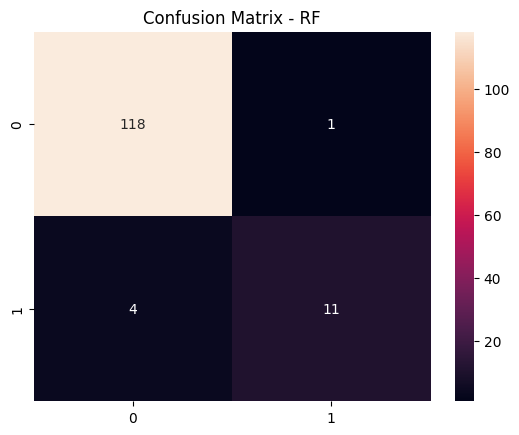

In [30]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - RF")
plt.show()